In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# QUESTION 01
 From Lab 6: Differentiation and Richardson

In [ ]:
def forward_diff(f, x, h):
    return (f(x + h) - f(x)) / h

def backward_diff(f, x, h):
    return (f(x) - f(x - h)) / h

# 1(a)
def central_diff(f, x, h):
    return (forward_diff(f, x, h) + backward_diff(f, x, h)) / 2

In [ ]:
#1b
def formula_A(f, x, h):
    return (-3 * f(x) + 4 * f(x + h) - f(x + 2 * h)) / (2 * h)

def formula_B(f, x, h):
    return (f(x - 2 * h) - 8 * f(x - h) + 8 * f(x + h) - f(x + 2 * h)) / (12 * h)

In [ ]:
# 1(c)
x_point = np.pi / 4
step = 0.2
actual = np.cos(x_point)

print("Q1 central_diff:", central_diff(np.sin, x_point, step))

error_A = abs(actual - formula_A(np.sin, x_point, step))
error_B = abs(actual - formula_B(np.sin, x_point, step))

print("Q1 Formula A error:", error_A)
print("Q1 Formula B error:", error_B)

if error_A < error_B:
    print("Better formula: A")
else:
    print("Better formula: B")

Q1 central_diff: 0.7024021550949058
Q1 Formula A error: 0.007891838885678792
Q1 Formula B error: 3.753319739907557e-05
Better formula: B


# QUESTION 02
From Lab 2: Polynomial Interpolation (Vandermonde)

In [ ]:
#2a
def make_vandermonde(x):
    n = len(x)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            A[i, j] = x[i] ** (i + j)
    return A

x = np.array([0, 1, 2, 3])
y = np.array([3, 4, 60, 1296])
A = make_vandermonde(x)
print("\nQ2 matrix:\n", A)


Q2 matrix:
 [[  1.   0.   0.   0.]
 [  1.   1.   1.   1.]
 [  4.   8.  16.  32.]
 [ 27.  81. 243. 729.]]


In [ ]:
# 2b
A_inv = np.linalg.inv(A)
coeff = np.dot(A_inv, y)
p = Polynomial(coeff)
print("Q2 coefficients:", coeff)
print("Q2 polynomial:", p)

Q2 coefficients: [ 3.  0. -1.  2.]
Q2 polynomial: 3.0 + 0.0·x - 1.0·x² + 2.0·x³


Q2 p(4) = 115.0


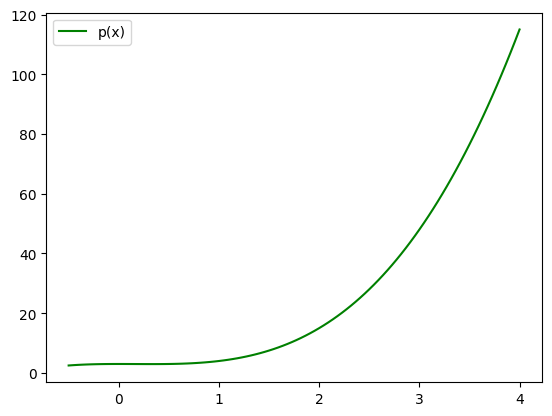

In [ ]:
print("Q2 p(4) =", p(4))
x2 = np.linspace(-0.5, 4, 100)
y2 = p(x2)
plt.plot(x2, y2, 'g-', label='p(x)')
plt.legend()
plt.show()

# QUESTION 03
From Lab 3: Lagrange Interpolation

In [ ]:
# 3a
def l_k(data_X, k, x):
    result = 1.0
    for j in range(len(data_X)):
        if j != k:
            result *= (x - data_X[j]) / (data_X[k] - data_X[j])
    return result

In [ ]:
# 3b
def get_poly_lagrange(data_X, data_Y, x_arr):
    answers = []
    for x_value in x_arr:
        total = 0.0
        for k in range(len(data_X)):
            total += data_Y[k] * l_k(data_X, k, x_value)
        answers.append(total)
    return np.array(answers)

data_X = np.array([1, 2, 4])
data_Y = np.array([3, 5, 4])
x_arr = np.array([0, 3, 5])
print("\nQ3 l_1(3) =", l_k(data_X, 1, 3))
print("Q3 P(x_arr) =", get_poly_lagrange(data_X, data_Y, x_arr))


Q3 l_1(3) = 1.0
Q3 P(x_arr) = [-0.66666667  5.33333333  1.        ]


# QUESTION 04
From Lab 5: Hermite Interpolation

In [ ]:
# 4a
hx = np.array([0, 1, 2])
hy = np.cos(hx) + hx
hdy = -np.sin(hx) + 1
print("\nQ4 hy :", hy)
print("Q4 hdy:", hdy)


Q4 hy : [1.         1.54030231 1.58385316]
Q4 hdy: [1.         0.15852902 0.09070257]


In [ ]:
# 4b
def l_k4(xs, k, x):
    r = 1.0
    for j in range(len(xs)):
        if j != k:
            r *= (x - xs[j]) / (xs[k] - xs[j])
    return r

def dl_node(xs, k):
    return sum(1 / (xs[k] - xs[j]) for j in range(len(xs)) if j != k)

def h_k(xs, k, x):
    return (1 - 2 * (x - xs[k]) * dl_node(xs, k)) * l_k4(xs, k, x) ** 2

def h_hat_k(xs, k, x):
    return (x - xs[k]) * l_k4(xs, k, x) ** 2

def H(xs, ys, dys, x):
    total = 0.0
    for k in range(len(xs)):
        total += ys[k] * h_k(xs, k, x) + dys[k] * h_hat_k(xs, k, x)
    return total

print("Q4 H(1.5) =", H(hx, hy, hdy, 1.5))
print("Q4 actual g(1.5) =", np.cos(1.5) + 1.5)

Q4 H(1.5) = 1.5708271856736837
Q4 actual g(1.5) = 1.5707372016677028
